In [ ]:
!pip install prophet

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pickle

In [4]:
energy = pd.read_csv("Total_energy.csv")
weather = pd.read_csv("Total_weather.csv")

In [5]:
energy.head(3)

,Year,Month,Day,Hour,Weekday,Electricity,PV,Cooling,Heat,Emission,Total Energy
0,2014,1,1,0,2,17948.45,1.35,1978.52,8.08,14.804,93.040
1,2014,1,1,1,2,17869.61,1.00,1840.76,8.14,14.512,91.171
2,2014,1,1,2,2,18209.09,3.36,1814.95,8.22,14.656,92.106


In [6]:
weather.head(3)

,Year,Month,Day,Hour,DOW,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precip
0,2014,1,1,0,2,53.0,0.0,45.0,0.0,0.0,28.86,0.0
1,2014,1,1,1,2,51.0,33.0,50.0,5.0,0.0,28.86,0.0
2,2014,1,1,2,2,50.0,0.0,50.0,3.0,0.0,28.86,0.0


In [7]:
df = pd.merge(energy, weather, on=['Year', 'Month', 'Hour', 'Day'], how='inner')
print(df.Year.min(), "to", df.Year.max())

2014 to 2022


In [8]:
dfwithdatetime = df.copy()

dfwithdatetime['Datetime'] = pd.to_datetime(dfwithdatetime[['Year', 'Month', 'Day', 'Hour']])
dfwithdatetime.drop(["Year","Month","Day","Hour","Weekday"],axis = 'columns', inplace = True)
dfwithdatetime.drop(["Cooling", "Heat", "Emission", "DOW", "Total Energy", "Electricity"], axis='columns', inplace=True)

dfwithdatetime

,PV,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precip,Datetime
0,1.35,53.0,0.0,45.0,0.0,0.0,28.86,0.0,2014-01-01 00:00:00
1,1.00,51.0,33.0,50.0,5.0,0.0,28.86,0.0,2014-01-01 01:00:00
2,3.36,50.0,0.0,50.0,3.0,0.0,28.86,0.0,2014-01-01 02:00:00
3,8.72,49.0,0.0,52.0,6.0,0.0,28.86,0.0,2014-01-01 03:00:00
4,8.92,49.0,0.0,52.0,0.0,0.0,28.87,0.0,2014-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...
78883,1.66,62.0,50.0,65.0,7.0,0.0,28.73,0.0,2022-12-31 19:00:00
78884,1.64,59.0,50.0,72.0,5.0,0.0,28.73,0.0,2022-12-31 20:00:00
78885,1.71,59.0,50.0,72.0,3.0,0.0,28.72,0.0,2022-12-31 21:00:00
78886,1.77,58.0,49.0,72.0,0.0,0.0,28.71,0.0,2022-12-31 22:00:00


In [9]:
dfp = dfwithdatetime.rename(columns={'Datetime': 'ds', 'PV': 'y'})

In [10]:
# Load the model
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

train = dfp.iloc[:-30000,:]
test = dfp.iloc[-30000:-5000,:]

pred = model.predict(test)

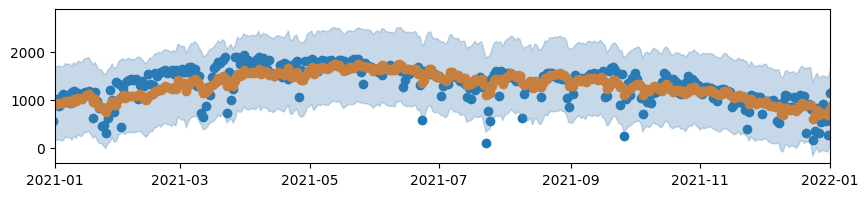

In [11]:
test_daily = test.resample('1D', on='ds').mean().reset_index()
train_daily = train.resample('1D', on='ds').mean().reset_index()
pred_daily = pred.resample('1D', on='ds').mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 2))

ax.scatter(test_daily["ds"], test_daily["y"])
ax.scatter(pred_daily["ds"], pred_daily["yhat"])
ax.scatter(train_daily["ds"], train_daily["y"])

ax.fill_between(pred_daily['ds'], pred_daily['yhat_lower'], pred_daily['yhat_upper'], alpha=0.3, color='steelblue', label='Confidence Interval')

ax.set_xlim(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-01-01'))

plt.show()

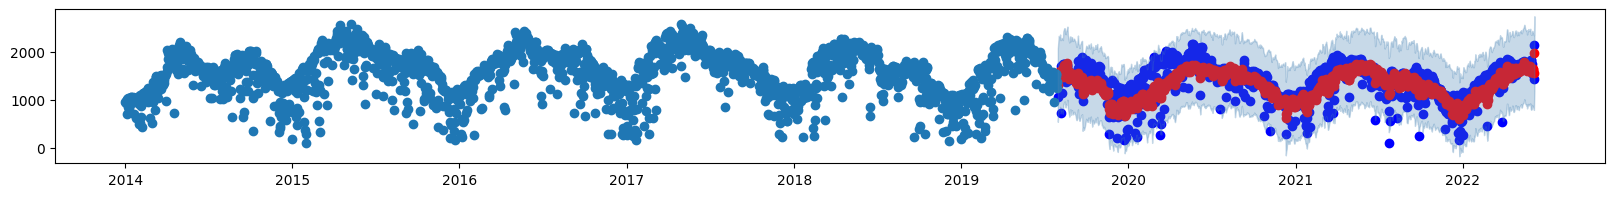

In [12]:
fig, ax = plt.subplots(figsize=(20, 2))

ax.scatter(test_daily["ds"], test_daily["y"], c = 'blue')
ax.scatter(pred_daily["ds"], pred_daily["yhat"], c = 'red')
ax.scatter(train_daily["ds"], train_daily["y"])

ax.fill_between(pred_daily['ds'], pred_daily['yhat_lower'], pred_daily['yhat_upper'], alpha=0.3, color='steelblue', label='Confidence Interval')

plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

mean_absolute_percentage_error(test_daily["y"], pred_daily["yhat"])

0.19333396364095867

In [14]:
#How many days to test
days = 20
#How strict to test
threshold = 100

anomaly = dfp.iloc[-(days*24):,:]
anomaly.to_csv('trial.csv', index=False)

trial = pd.read_csv("trial.csv")
trial['ds'] = pd.to_datetime(trial['ds'])

trial_daily = trial.resample('1D', on='ds').mean().reset_index()
trial_daily

,ds,y,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precip
0,2022-12-12,766.185417,51.791667,37.750000,61.333333,8.500000,2.541667,28.628750,0.004167
1,2022-12-13,681.521667,48.291667,37.125000,66.416667,5.916667,0.916667,28.767500,0.000000
2,2022-12-14,1090.140833,45.916667,33.500000,64.125000,3.833333,0.000000,28.912083,0.000000
3,2022-12-15,1031.010833,47.083333,32.333333,58.500000,3.958333,0.000000,28.910417,0.000000
4,2022-12-16,869.662083,49.375000,29.125000,49.166667,4.166667,0.000000,28.905000,0.000000
5,2022-12-17,946.811667,48.833333,18.791667,33.041667,3.708333,0.000000,28.853750,0.000000
6,2022-12-18,594.178333,51.916667,28.000000,40.416667,3.708333,0.000000,28.770000,0.000000
7,2022-12-19,869.926250,50.375000,33.125000,54.083333,3.166667,0.000000,28.981250,0.000000
8,2022-12-20,667.154167,52.000000,32.208333,49.500000,3.583333,0.000000,29.000417,0.000000
9,2022-12-21,990.323333,51.708333,31.958333,49.833333,2.500000,0.000000,28.882500,0.000000


In [15]:
output = model.predict(trial)

output_daily = output.resample('1D', on='ds').mean().reset_index()
output_daily.to_csv('output.csv', index=False)

# Merge on date so rows are aligned by ds, not position
merged = output_daily[['ds', 'yhat']].merge(trial_daily[['ds', 'y']], on='ds', how='inner')

merged['diff'] = abs(merged['yhat'] - merged['y'])
merged['anomaly'] = merged['diff'].apply(lambda d: 'Anomaly Detected' if d > threshold else None)

trial_daily_anomalies = trial_daily.merge(
    merged[['ds', 'diff', 'anomaly']], on='ds', how='left'
)

trial_daily_anomalies.to_csv('trial_daily_anomalies.csv', index=False)
trial_daily_anomalies


,ds,y,Temperature,Dew Point,Humidity,Wind Speed,Wind Gust,Pressure,Precip,diff,anomaly
0,2022-12-12,766.185417,51.791667,37.750000,61.333333,8.500000,2.541667,28.628750,0.004167,110.795145,Anomaly Detected
1,2022-12-13,681.521667,48.291667,37.125000,66.416667,5.916667,0.916667,28.767500,0.000000,10.056799,None
2,2022-12-14,1090.140833,45.916667,33.500000,64.125000,3.833333,0.000000,28.912083,0.000000,379.229820,Anomaly Detected
3,2022-12-15,1031.010833,47.083333,32.333333,58.500000,3.958333,0.000000,28.910417,0.000000,309.481611,Anomaly Detected
4,2022-12-16,869.662083,49.375000,29.125000,49.166667,4.166667,0.000000,28.905000,0.000000,84.306869,None
5,2022-12-17,946.811667,48.833333,18.791667,33.041667,3.708333,0.000000,28.853750,0.000000,77.038761,None
6,2022-12-18,594.178333,51.916667,28.000000,40.416667,3.708333,0.000000,28.770000,0.000000,237.087384,Anomaly Detected
7,2022-12-19,869.926250,50.375000,33.125000,54.083333,3.166667,0.000000,28.981250,0.000000,90.323823,None
8,2022-12-20,667.154167,52.000000,32.208333,49.500000,3.583333,0.000000,29.000417,0.000000,147.510719,Anomaly Detected
9,2022-12-21,990.323333,51.708333,31.958333,49.833333,2.500000,0.000000,28.882500,0.000000,167.616094,Anomaly Detected
